# Plot single GLM-HMM performance 

In [22]:
import os
import numpy as np
import numpy.random as npr
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

import seaborn as sns
sns.set_context("paper")
sns.set_style("ticks")
# increse rc params for better visualization
plt.rcParams['font.size'] = 25

import pandas as pd
npr.seed(0)
import os

from plotting_utils import remove_top_right_frame, save_figure_to_files, lighten_color

##### Load the data

In [5]:
# Load the data

root_path = r'M:\analysis\Axel_Bisi\beh_model'
result_figure_path = r'M:\analysis\Axel_Bisi\beh_model\all_subjects_glmhmm_time\figures_time'
if not os.path.exists(result_figure_path):
    os.makedirs(result_figure_path)
    
subject_ids = [f for f in os.listdir(root_path) if 'AB' in f]

# Load the data
all_subjects_res = []
all_subjects_trial_data = []
splits = 10
n_states = [1,2,3,4,5]
n_states = [2,3]
for subject_id in subject_ids:
    for split_id in range(splits):
        for k_state in n_states:
            path_to_res_folder = os.path.join(root_path, subject_id, 'full_models_time', f'model_{split_id}', f'{k_state}_states', 'iter_0')
            
            # Load model results
            path_to_res_file = os.path.join(path_to_res_folder,  'fit_glmhmm_results.npz')
            try:
                res = np.load(path_to_res_file, allow_pickle=True)['arr_0'][()]
                all_subjects_res.append(res)
            except:
                continue
                
            # Load trial data
            path_to_data_file = os.path.join(path_to_res_folder,  'data_preds.h5')
            try:
                trial_data = pd.read_hdf(path_to_data_file)
                trial_data['n_states'] = k_state
                trial_data['split_idx'] = split_id
                all_subjects_trial_data.append(trial_data)
                
            except:
                continue
            

# Make dataframe
all_subjects_res = pd.DataFrame(all_subjects_res)

all_subjects_trial_data = pd.concat(all_subjects_trial_data)

#### Inspect dataframe

In [6]:
# Average per data splits first
all_subjects_res_avg = all_subjects_res.groupby(['subject_id', 'n_states']).agg({'ll_train': 'mean', 'll_test': 'mean', 'predictive_acc_train': 'mean', 'predictive_acc_test': 'mean'}).reset_index()
all_subjects_res_avg

,subject_id,n_states,ll_train,ll_test,predictive_acc_train,predictive_acc_test
0,AB072,2,-308.846229,-58.882742,0.825979,0.891667
1,AB072,3,-464.115749,-110.742727,0.767717,0.775543
2,AB073,2,-169.872602,-48.649426,0.861044,0.860000
3,AB073,3,-266.285169,-81.736013,0.767894,0.764583
4,AB074,2,-72.428371,-23.247496,0.901575,0.859375
...,...,...,...,...,...,...
85,AB128,3,-498.668763,-114.909565,0.802913,0.822835
86,AB129,2,-377.483475,-93.841715,0.865714,0.882591
87,AB129,3,-527.523056,-140.322517,0.758251,0.792473
88,AB130,3,-439.593842,-117.756803,0.732848,0.697222


#### Plots log-likelihood for every mouse
Note: LL depends on the number of trials, therfore bits per trial is more meaningful or predictive accuracy
Note: can calculate difference relative to 1-state model

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


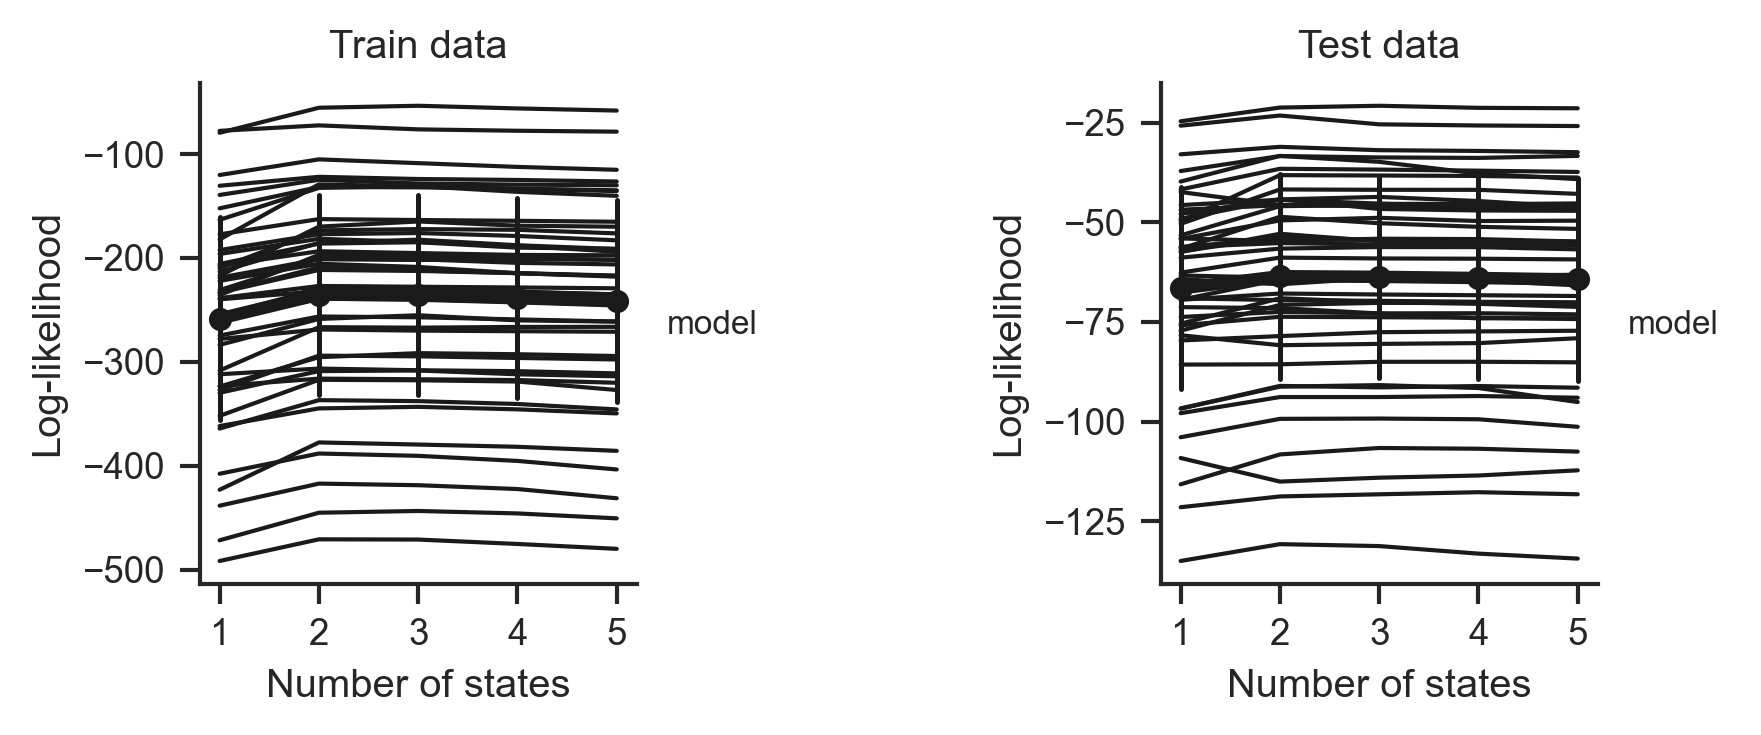

In [383]:

# Plot log likelihood 
fig, axs = plt.subplots(1, 2, figsize=(6, 3), dpi=300)

# Train data
axs[0].set_title('Train data')
sns.lineplot(x='n_states', y='ll_train', data=all_subjects_res_avg, ax=axs[0], estimator=np.mean, errorbar='sd',err_style='bars', lw=3, c='k', markers=True, marker='o', markeredgecolor=None)
sns.lineplot(x='n_states', y='ll_train', data=all_subjects_res_avg, ax=axs[0], units='subject_id', estimator=None,
             lw=1, c='k')
axs[0].set_ylabel('Log-likelihood')
axs[0].set_xlabel('Number of states')
axs[0].set_xticks([1,2,3,4,5])

# Test data
axs[1].set_title('Test data')
sns.lineplot(x='n_states', y='ll_test', data=all_subjects_res_avg, ax=axs[1], estimator=np.mean, errorbar='sd',err_style='bars', lw=3, c='k', markers=True, marker='o', markeredgecolor=None)
sns.lineplot(x='n_states', y='ll_test', data=all_subjects_res_avg, ax=axs[1], units='subject_id', estimator=None,
             lw=1, c='k')
axs[1].set_ylabel('Log-likelihood')
axs[1].set_xlabel('Number of states')
axs[1].set_xticks([1,2,3,4,5])

for ax in axs.flat:
    remove_top_right_frame(ax)
    box = ax.get_position()
    ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
    ax.legend(loc='center left', title='model', bbox_to_anchor=(1, 0.5), frameon=False, fontsize=8, title_fontsize=8)


fig.tight_layout()
plt.subplots_adjust(wspace=1.2)
save_figure_to_files(fig=fig, save_path=result_figure_path, file_name='models_ll', 
                     suffix=None, file_types=['png', 'svg'], dpi=200)


#### Plots predictive accuracy

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


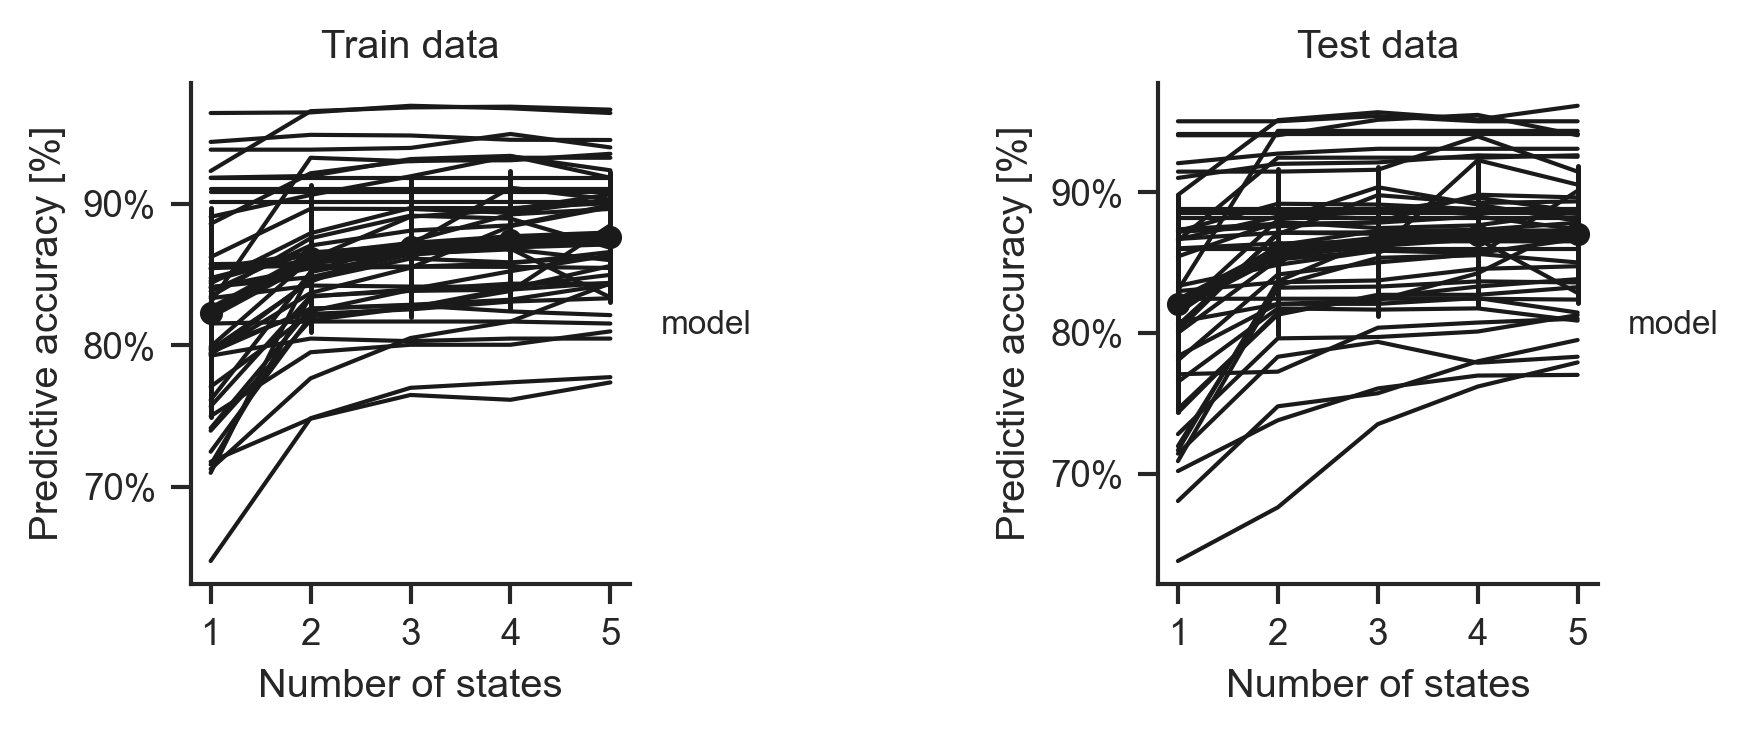

In [384]:


fig, axs = plt.subplots(1, 2, figsize=(6, 3), dpi=300)

# Train data
axs[0].set_title('Train data')
sns.lineplot(x='n_states', y='predictive_acc_train', data=all_subjects_res_avg, ax=axs[0], estimator=np.mean, errorbar='sd',err_style='bars', lw=3, c='k', markers=True, marker='o', markeredgecolor=None)
sns.lineplot(x='n_states', y='predictive_acc_train', data=all_subjects_res_avg, ax=axs[0], units='subject_id', estimator=None,
             lw=1, c='k')
axs[0].set_ylabel('Predictive accuracy [%]')
axs[0].set_xlabel('Number of states')
axs[0].set_xticks([1,2,3,4,5])
axs[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0,decimals=0))


# Test data
axs[1].set_title('Test data')
sns.lineplot(x='n_states', y='predictive_acc_test', data=all_subjects_res_avg, ax=axs[1], estimator=np.mean, errorbar='sd',err_style='bars', lw=3, c='k', markers=True, marker='o', markeredgecolor=None)
sns.lineplot(x='n_states', y='predictive_acc_test', data=all_subjects_res_avg, ax=axs[1], units='subject_id', estimator=None,
             lw=1, c='k')
axs[1].set_ylabel('Predictive accuracy [%]')
axs[1].set_xlabel('Number of states')
axs[1].set_xticks([1,2,3,4,5])
axs[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))

for ax in axs.flat:
    remove_top_right_frame(ax)
    box = ax.get_position()
    ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
    ax.legend(loc='center left', title='model', bbox_to_anchor=(1, 0.5), frameon=False, fontsize=8, title_fontsize=8)

fig.tight_layout()
plt.subplots_adjust(wspace=1.2)
save_figure_to_files(fig=fig, save_path=result_figure_path, file_name='models_pred_acc', 
                     suffix=None, file_types=['png', 'svg'], dpi=200)


#### Plot model weights across states and mice


In [7]:
# Select example data and format
split_idx = 0
n_states = 2
all_models_res_df_split = all_subjects_res[(all_subjects_res['split_idx']==0)
                            & (all_subjects_res['n_states']==n_states)]


# Flatten weight array from 3d to 1d
all_models_res_df_split.loc[:, 'weights'] = all_models_res_df_split['weights'].apply(lambda x: np.array(x.flatten()))
all_models_res_df_split.loc[:, 'features'] = all_models_res_df_split['features'].apply(lambda x: x * n_states) # repeat content of features

# Explode columns jointly now that they match in size
all_models_res_df_split = all_models_res_df_split.explode(['features', 'weights']).reset_index(drop=True)
all_models_res_df_split['reward_group'] = all_models_res_df_split['reward_group'].astype(int)

# Create a state_idx column
n_splits, n_features = all_models_res_df_split['split_idx'].nunique(), all_models_res_df_split['features'].nunique()
n_subjects = all_models_res_df_split['subject_id'].nunique()
state_pattern = np.concatenate([np.full(n_features, i) for i in range(n_states)])
all_models_res_df_split['state_idx'] = np.tile(state_pattern, n_splits*n_subjects)

# Inspect
all_models_res_df_split.head(20)


,subject_id,split_idx,n_states,instance_idx,features,weights,init_weights,transition_matrix,ll_train,ll_test,output_train_preds:,output_test_preds,predictive_acc_train,predictive_acc_test,reward_group,state_idx
0,AB072,0,2,0,bias,-0.56436,"[[[-2.439799946155213, -1.2936664824158925, -2...","[[0.4782094833669062, 0.5217905166330938], [0....",-313.697335,-58.706476,"[[1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0,...","[[0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,...",0.822454,0.888889,2,0
1,AB072,0,2,0,whisker,-0.123716,"[[[-2.439799946155213, -1.2936664824158925, -2...","[[0.4782094833669062, 0.5217905166330938], [0....",-313.697335,-58.706476,"[[1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0,...","[[0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,...",0.822454,0.888889,2,0
2,AB072,0,2,0,auditory,-0.217243,"[[[-2.439799946155213, -1.2936664824158925, -2...","[[0.4782094833669062, 0.5217905166330938], [0....",-313.697335,-58.706476,"[[1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0,...","[[0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,...",0.822454,0.888889,2,0
3,AB072,0,2,0,time_since_last_auditory_stim,-0.379943,"[[[-2.439799946155213, -1.2936664824158925, -2...","[[0.4782094833669062, 0.5217905166330938], [0....",-313.697335,-58.706476,"[[1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0,...","[[0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,...",0.822454,0.888889,2,0
4,AB072,0,2,0,time_since_last_whisker_stim,-0.321164,"[[[-2.439799946155213, -1.2936664824158925, -2...","[[0.4782094833669062, 0.5217905166330938], [0....",-313.697335,-58.706476,"[[1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0,...","[[0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,...",0.822454,0.888889,2,0
5,AB072,0,2,0,time_since_last_auditory_reward,-0.452533,"[[[-2.439799946155213, -1.2936664824158925, -2...","[[0.4782094833669062, 0.5217905166330938], [0....",-313.697335,-58.706476,"[[1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0,...","[[0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,...",0.822454,0.888889,2,0
6,AB072,0,2,0,time_since_last_whisker_reward,-0.654244,"[[[-2.439799946155213, -1.2936664824158925, -2...","[[0.4782094833669062, 0.5217905166330938], [0....",-313.697335,-58.706476,"[[1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0,...","[[0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,...",0.822454,0.888889,2,0
7,AB072,0,2,0,bias,-2.413847,"[[[-2.439799946155213, -1.2936664824158925, -2...","[[0.4782094833669062, 0.5217905166330938], [0....",-313.697335,-58.706476,"[[1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0,...","[[0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,...",0.822454,0.888889,2,1
8,AB072,0,2,0,whisker,-1.487572,"[[[-2.439799946155213, -1.2936664824158925, -2...","[[0.4782094833669062, 0.5217905166330938], [0....",-313.697335,-58.706476,"[[1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0,...","[[0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,...",0.822454,0.888889,2,1
9,AB072,0,2,0,auditory,-2.645945,"[[[-2.439799946155213, -1.2936664824158925, -2...","[[0.4782094833669062, 0.5217905166330938], [0....",-313.697335,-58.706476,"[[1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0,...","[[0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,...",0.822454,0.888889,2,1


In [8]:
# Trial-data example data and format
split_idx = 0
n_states = 2
all_subjects_trial_data_split = all_subjects_trial_data[(all_subjects_trial_data['split_idx']==split_idx)
                            & (all_subjects_trial_data['n_states']==n_states)]


# Assign most likely states to each trial looking into posterior columns
posterior_cols = [col for col in all_subjects_trial_data_split.columns if 'posterior' in col]
# Rename posterior cols to remove index starting at 1
all_subjects_trial_data_split = all_subjects_trial_data_split.rename(columns={col: f'posterior_{i-1}' for i, col in enumerate(posterior_cols, 1)})
posterior_cols = [col for col in all_subjects_trial_data_split.columns if 'posterior' in col]
all_subjects_trial_data_split['most_likely_state'] = all_subjects_trial_data_split[posterior_cols].idxmax(axis=1).apply(lambda x: int(x[-1]))
all_subjects_trial_data_split['most_likely_state'] = all_subjects_trial_data_split['most_likely_state'].astype(int)



2


C:\Users\bisi\AppData\Local\Temp\ipykernel_6100\921427894.py:16: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(y='features', x='weights', data=weights_df, ax=axs[state_idx], color=color, scale=0.8)
C:\Users\bisi\AppData\Local\Temp\ipykernel_6100\921427894.py:16: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(y='features', x='weights', data=weights_df, ax=axs[state_idx], color=color, scale=0.8)
C:\Users\bisi\AppData\Local\Temp\ipykernel_6100\921427894.py:16: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g.

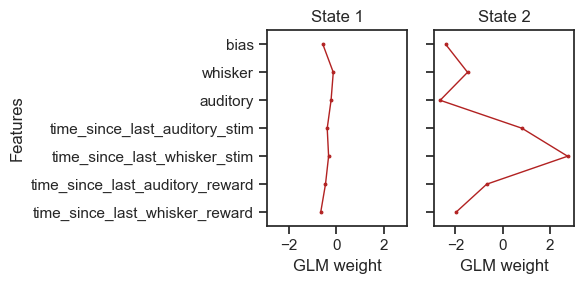

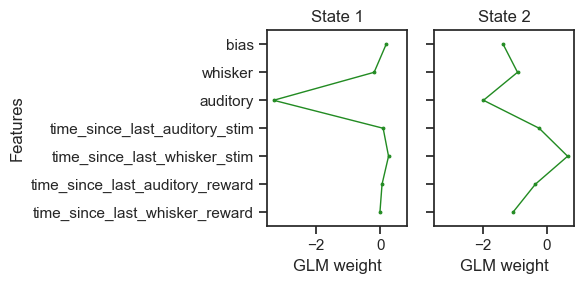

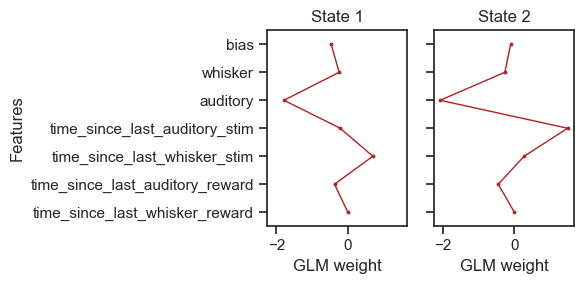

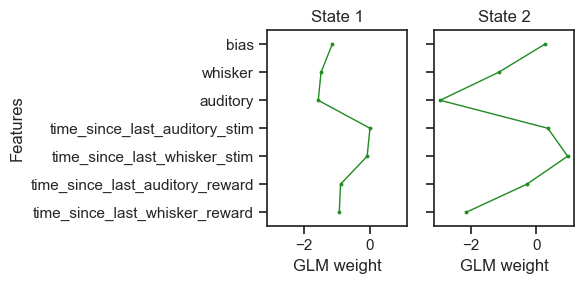

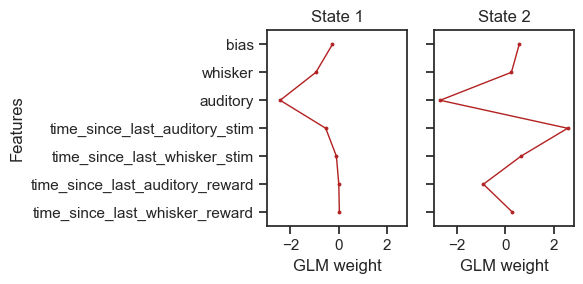

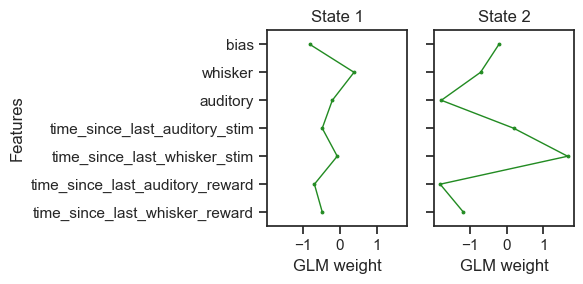

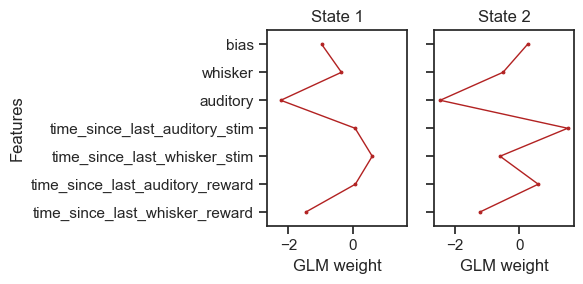

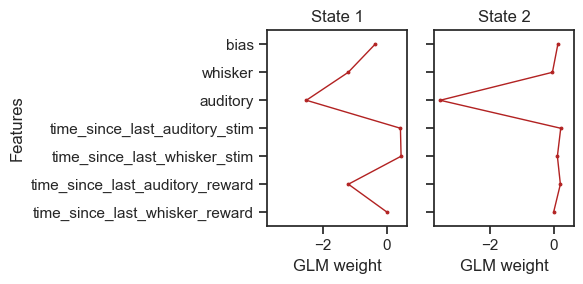

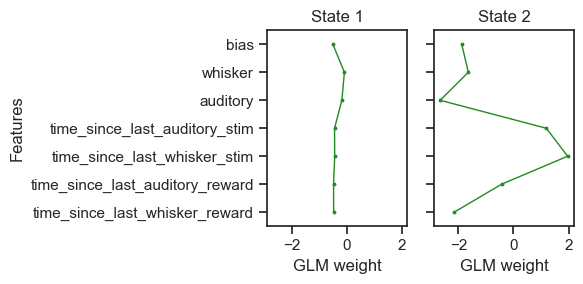

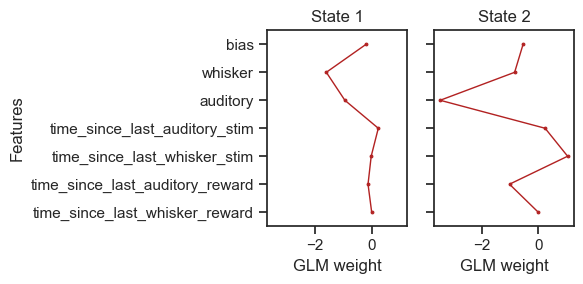

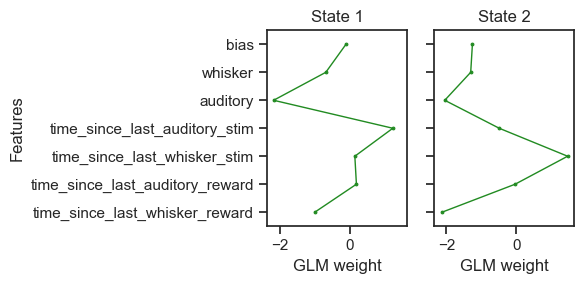

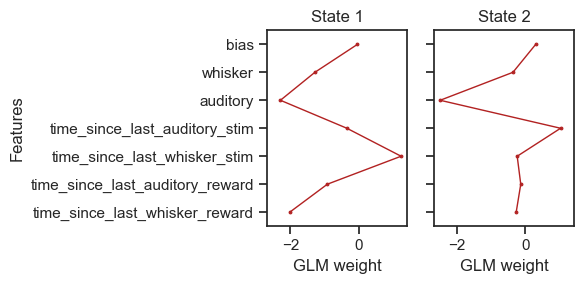

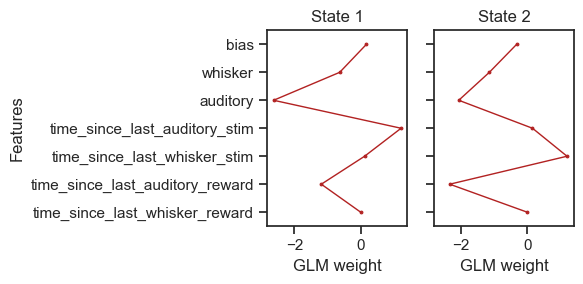

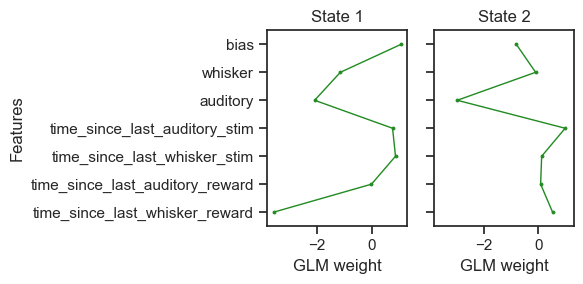

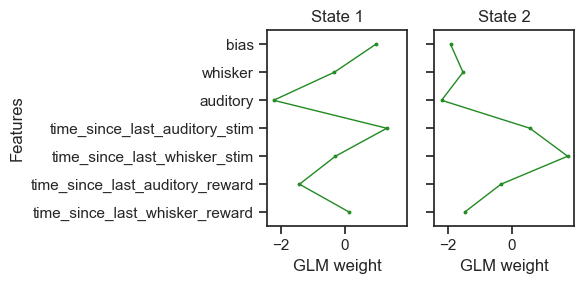

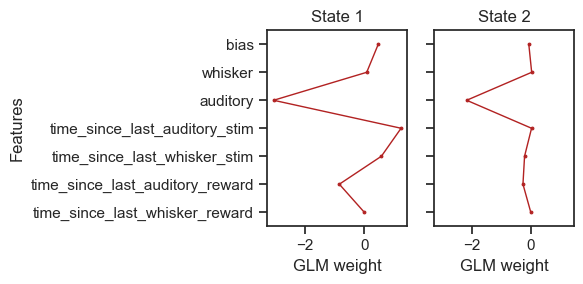

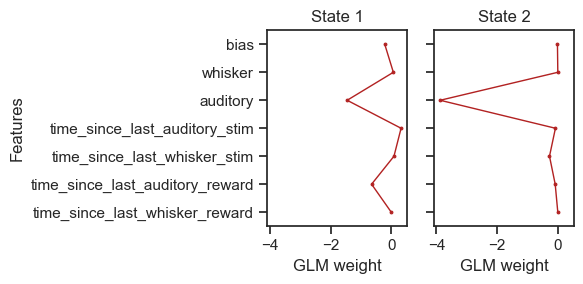

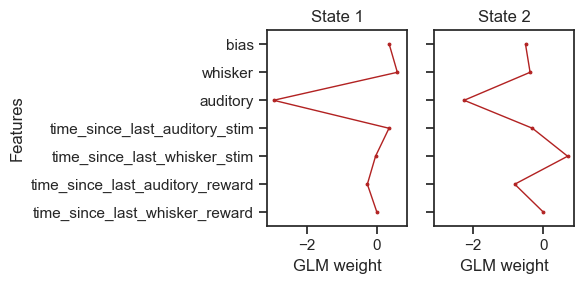

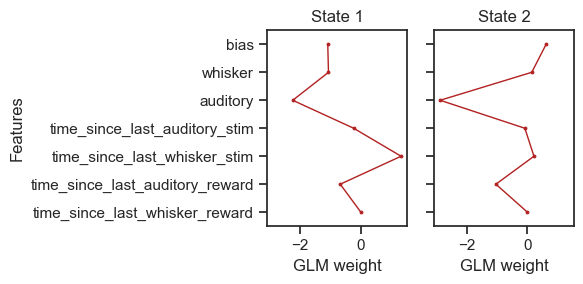

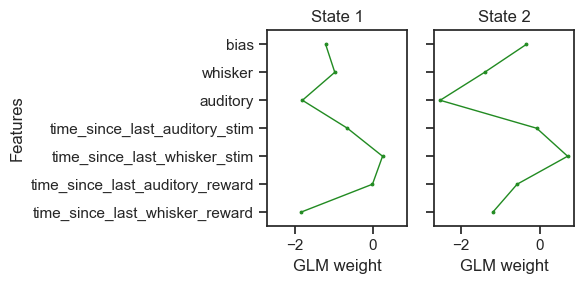

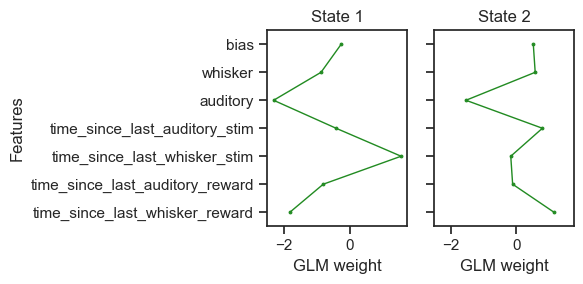

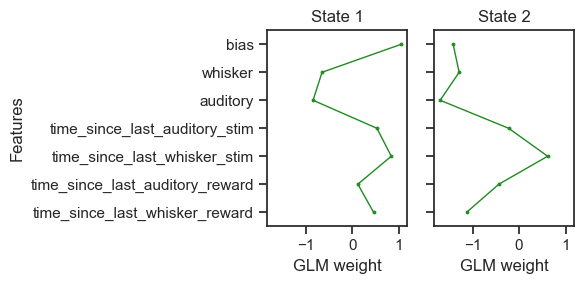

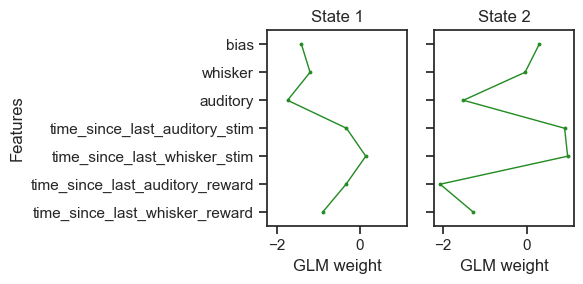

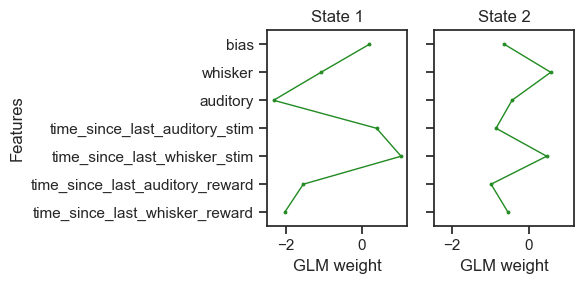

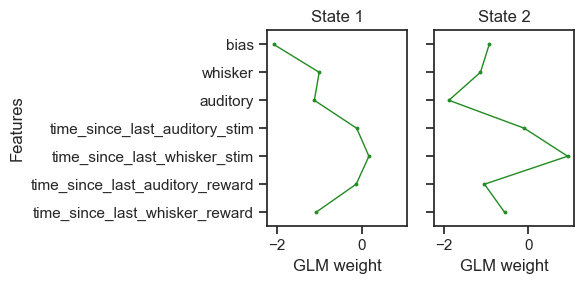

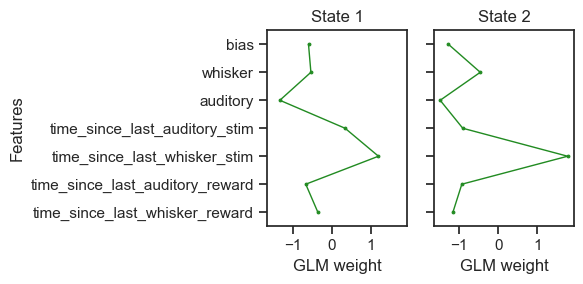

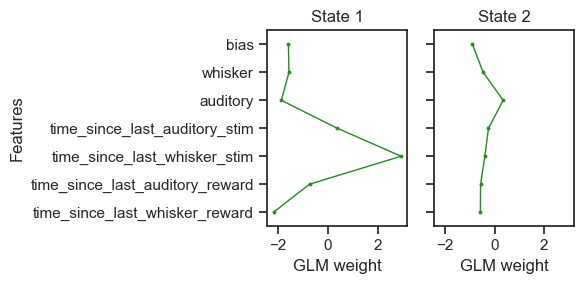

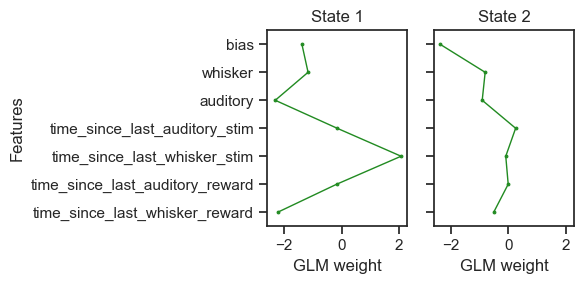

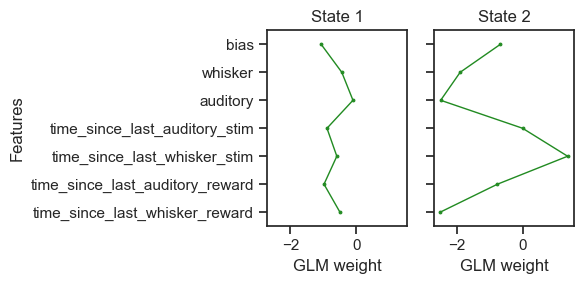

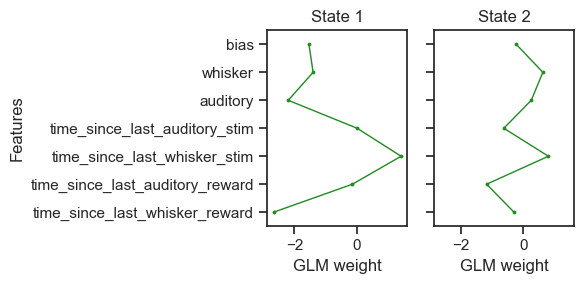

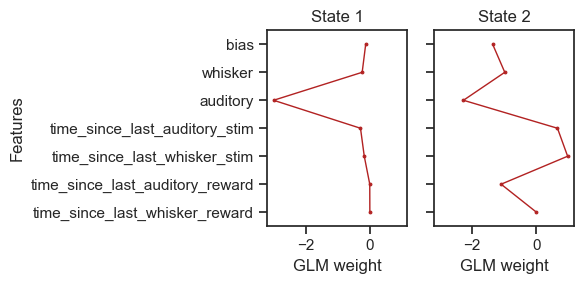

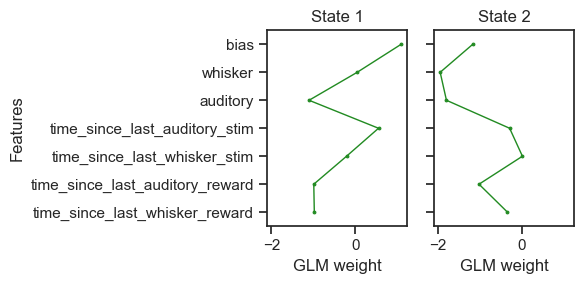

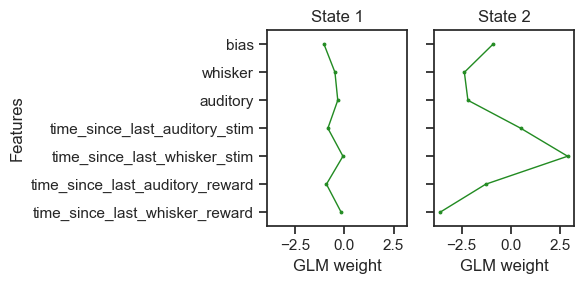

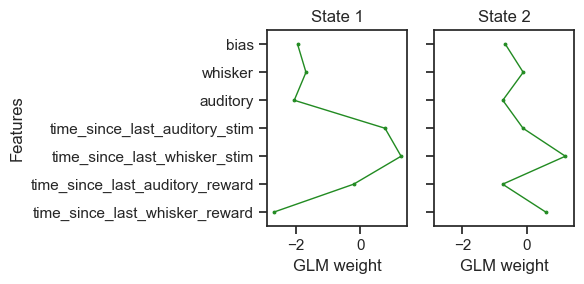

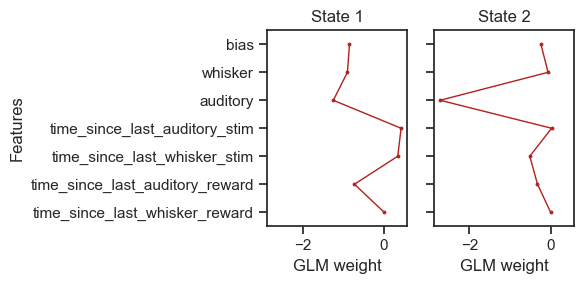

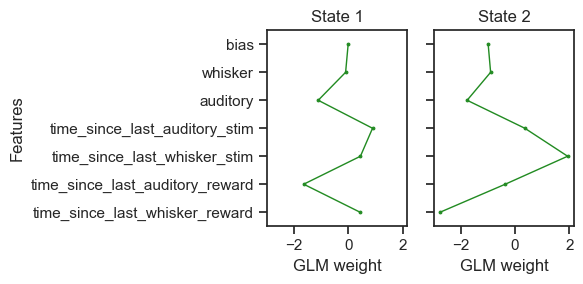

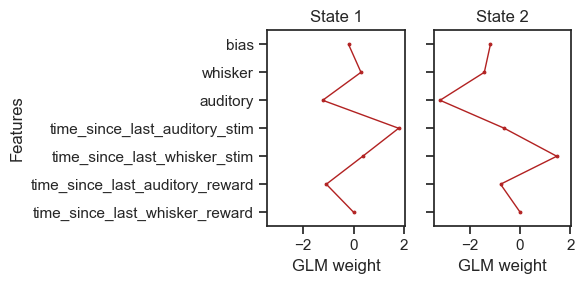

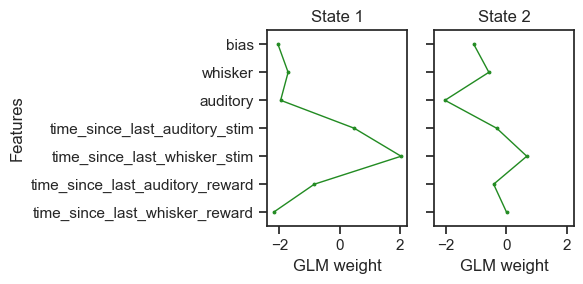

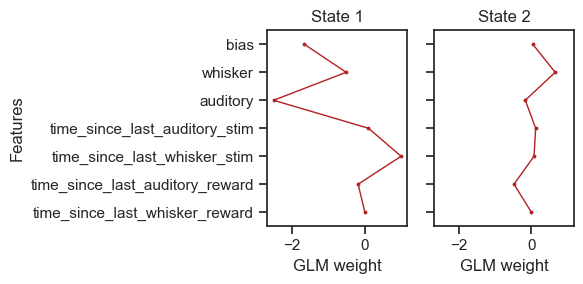

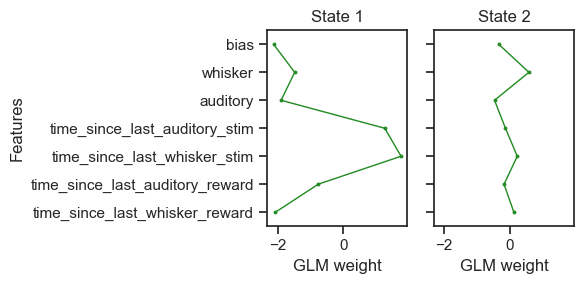

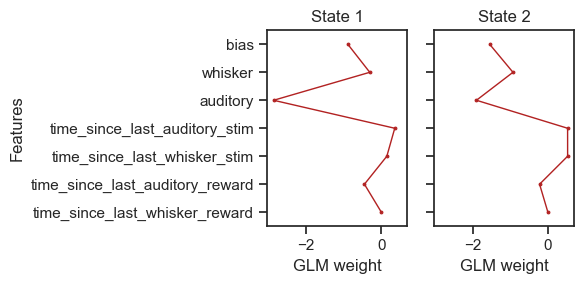

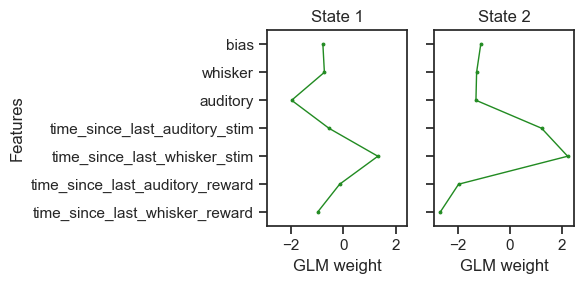

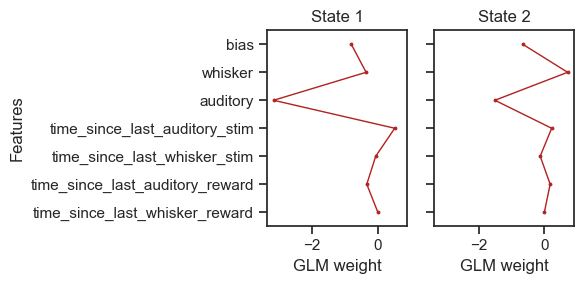

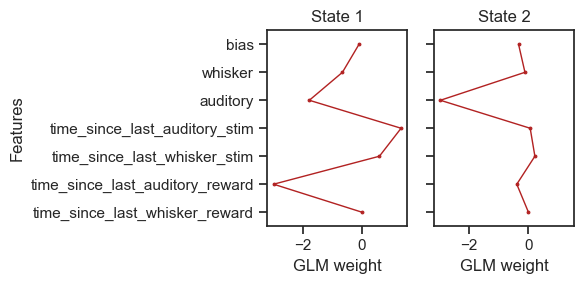

In [11]:
#### Make one figure per mice, for states 2 and 3
# Make figure including all mice
sns.set(style="ticks", rc={"lines.linewidth": 0.7})
n_states = all_models_res_df_split['n_states'].unique()[0]
print(n_states)

for subject_id in all_models_res_df_split['subject_id'].unique():
    fig, axs = plt.subplots(1, n_states, figsize=(3*n_states, 3), dpi=100, sharey=True, sharex=True)

    for state_idx in range(n_states):
        # Get weights and reward group
        weights_df = all_models_res_df_split[(all_models_res_df_split['subject_id']==subject_id) & (all_models_res_df_split['state_idx'] == state_idx)]
        color = 'forestgreen' if weights_df['reward_group'].iloc[0] == 1 else 'firebrick'
        
        # Plot weights and legend
        sns.pointplot(y='features', x='weights', data=weights_df, ax=axs[state_idx], color=color, scale=0.8)
        axs[state_idx].set_title(f'State {state_idx+1}')
        axs[state_idx].set_xlabel('GLM weight', fontsize=12)
        axs[state_idx].set_ylabel('Features', fontsize=12)
        #remove_top_right_frame(axs[state_idx])

    fig.tight_layout()
    
    # Save figure for subject
    file_name = f'{subject_id}_{n_states}_states_models_weights_split_{0}'
    #save_figure_to_files(fig=fig, save_path=result_figure_path, file_name=file_name,
    #                     suffix=None, file_types=['png', 'svg'], dpi=200)

C:\Users\bisi\AppData\Local\Temp\ipykernel_6100\4013669642.py:13: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(y='features', x='weights', data=weights_df, ax=axs[state_idx], color=color, scale=0.8)
C:\Users\bisi\AppData\Local\Temp\ipykernel_6100\4013669642.py:13: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(y='features', x='weights', data=weights_df, ax=axs[state_idx], color=color, scale=0.8)
C:\Users\bisi\AppData\Local\Temp\ipykernel_6100\4013669642.py:13: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e

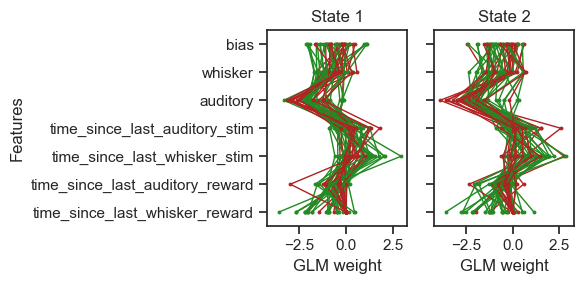

In [12]:
# Make figure including all mice
sns.set(style="ticks", rc={"lines.linewidth": 0.7})
fig, axs = plt.subplots(1, n_states, figsize=(3*n_states, 3), dpi=100, sharey=True, sharex=True)

for subject_id in all_models_res_df_split['subject_id'].unique():
    for state_idx in range(n_states):
        
        # Get weights and reward group
        weights_df = all_models_res_df_split[(all_models_res_df_split['subject_id']==subject_id) & (all_models_res_df_split['state_idx'] == state_idx)]
        color = 'forestgreen' if weights_df['reward_group'].iloc[0] == 1 else 'firebrick'
        
        # Plot weights and legend
        sns.pointplot(y='features', x='weights', data=weights_df, ax=axs[state_idx], color=color, scale=0.8)
        axs[state_idx].set_title(f'State {state_idx+1}')
        axs[state_idx].set_xlabel('GLM weight', fontsize=12)
        axs[state_idx].set_ylabel('Features', fontsize=12)
        #remove_top_right_frame(axs[state_idx])

fig.tight_layout()

# Save figure
file_name = f'{n_states}_states_models_weights_all_subjects_split_{0}'
#save_figure_to_files(fig=fig, save_path=result_figure_path, file_name=file_name,
#                     suffix=None, file_types=['png', 'svg'], dpi=200)

In [14]:
from utils import align_states_across_subjects

In [15]:
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import euclidean, cityblock

def compute_state_overlap(z1, z2, K1=None, K2=None):
    assert z1.dtype == int and z2.dtype == int
    assert z1.shape == z2.shape
    assert z1.min() >= 0 and z2.min() >= 0

    K1 = z1.max() + 1 if K1 is None else K1
    K2 = z2.max() + 1 if K2 is None else K2

    overlap = np.zeros((K1, K2))
    for k1 in range(K1):
        for k2 in range(K2):
            overlap[k1, k2] = np.sum((z1 == k1) & (z2 == k2))
    return overlap


def find_permutation(z1, z2, K1=None, K2=None):
    overlap = compute_state_overlap(z1, z2, K1=K1, K2=K2)
    K1, K2 = overlap.shape

    tmp, perm = linear_sum_assignment(-overlap)
    assert np.all(tmp == np.arange(K1)), "All indices should have been matched!"

    # Pad permutation if K1 < K2
    if K1 < K2:
        unused = np.array(list(set(np.arange(K2)) - set(perm)))
        perm = np.concatenate((perm, unused))

    return perm


# Function to compute cosine similarity between two 1D vectors
def cosine_similarity(A, B):
    """Compute the cosine similarity between two vectors."""
    return np.dot(A, B) / (np.linalg.norm(A) * np.linalg.norm(B))

# Function to compute cosine distance between two 1D vectors
def cosine_distance(A, B):
    """Compute the cosine distance between two vectors."""
    return 1 - cosine_similarity(A, B)

# Function to compute a distance matrix between two sets of weights
def compute_distance_matrix(W1, W2, metric='cosine'):
    """
    Compute a distance matrix between two sets of 1D state weights.
    
    W1: 1D weights for states in subject 1 (array of size n_states)
    W2: 1D weights for states in subject 2 (array of size n_states)
    metric: Distance metric to use ('cosine' or 'euclidean')
    
    Returns: Distance matrix of shape (n_states, n_states)
    """
    n_states = len(W1)
    distance_matrix = np.zeros((n_states, n_states))
    
    for i in range(n_states):
        for j in range(n_states):
            if metric == 'cosine':
                distance_matrix[i, j] = cosine_distance(W1[i], W2[j])
            elif metric == 'euclidean':
                distance_matrix[i, j] = euclidean(W1[i], W2[j])
            elif metric == 'manhattan':
                distance_matrix[i, j] = cityblock(W1[i], W2[j])
            else:
                raise ValueError(f"Unknown metric: {metric}. Use 'cosine' or 'euclidean'.")
    
    return distance_matrix

def compute_distance(w1, w2, method='euclidean'):
    """
    Compute the distance matrix between states of two subjects (1D weights).
    :param w1: first 1d vector
    :param w2: second 1s vector
    :param method:
    :return:
    """
    if method=='euclidean':
        # Compute the Euclidean distance between states
        distance = np.linalg.norm(w1 - w2)
    elif method=='cosine':
        # Compute the cosine similarity between states
        distance = 1 - np.dot(w1[:, None], w2) / (np.linalg.norm(w1[:, None]) * np.linalg.norm(w2))
    else:
        raise ValueError(f"Invalid method: {method}")
    return distance


# Function to align states of a subject to a reference using the Hungarian algorithm
def align_states(reference_weights, subject_weights):
    """
    Align the states of a subject to a reference using the Hungarian algorithm.
    :param reference_weights:
    :param subject_weights:
    :return:
    """
    # Compute the distance matrix between the reference and the subject's states
    distance_matrix = compute_distance_matrix(reference_weights, subject_weights, metric='euclidean')

    # Use Hungarian algorithm to find the best matching
    row_ind, col_ind = linear_sum_assignment(distance_matrix)

    # Return the permuted state indices for the subject
    return col_ind


def align_states_across_subjects(w_subjects, use_mean_reference=True):
    """
    Align state indices across multiple subjects based on the similarity of their 1D weights.

    W_subjects: List of arrays where each array contains the 1D weights for each state of a subject.
    use_mean_reference: If True, align states to the mean state vector across all subjects.
                        If False, align to the first subject.

    Returns: List of permuted weight arrays, where each subject's states are aligned.
    """
    # Number of subjects
    n_subjects = len(w_subjects)

    # Compute the reference states (either from the mean or the first subject)
    if use_mean_reference: 
        # Compute the mean state vector across all subjects
        reference_weights = np.mean(w_subjects, axis=0)
    else:
        # Use the first subject as the reference
        reference_weights = w_subjects[0]

    # Initialize the list to store permuted weights for each subject
    aligned_subjects = []
    permutations = []

    print(reference_weights, reference_weights.shape)
    for s in range(n_subjects):
        # Align the states of the current subject to the reference
        #permuted_indices = find_permutation(reference_weights, w_subjects[s])
        permuted_indices = align_states(reference_weights, w_subjects[s])

        # Permute the subject's weights based on the matching indices
        permuted_weights = w_subjects[s][permuted_indices]
        # Print the permuted states, if any
        print(f"Permuted states for subject {s + 1}: {permuted_indices}")
        
        # Store the permuted weights
        aligned_subjects.append(permuted_weights)
        permutations.append(permuted_indices)

    return aligned_subjects, permutations



In [16]:
n_features = all_models_res_df_split['features'].nunique()
n_states = all_models_res_df_split['state_idx'].nunique()
all_models_res_df_split_rewarded = all_models_res_df_split[all_models_res_df_split.reward_group.isin([1,2])]
n_subjects_rewarded = all_models_res_df_split_rewarded['subject_id'].nunique()
W_subjects_rewarded= all_models_res_df_split[all_models_res_df_split.reward_group.isin([1,2])]['weights'].values.reshape(n_subjects_rewarded, n_states, n_features)

all_models_res_df_split_nonrewarded = all_models_res_df_split[all_models_res_df_split.reward_group.isin([0])]
n_subjects_nonrewarded = all_models_res_df_split_nonrewarded['subject_id'].nunique()
W_subjects_nonrewarded = all_models_res_df_split[all_models_res_df_split.reward_group.isin([0])]['weights'].values.reshape(n_subjects_nonrewarded, n_states, n_features)

aligned_subjects_rewarded, perm_indices_rewarded = align_states_across_subjects(W_subjects_rewarded, use_mean_reference=False)
aligned_subjects_nonrewarded, perm_indices_nonrewarded = align_states_across_subjects(W_subjects_nonrewarded, use_mean_reference=False)

# Assign permutations to mouse ids
subject_ids_rewarded = all_models_res_df_split_rewarded['subject_id'].unique()
subject_ids_nonrewarded = all_models_res_df_split_nonrewarded['subject_id'].unique()
perm_indices_rewarded = dict(zip(subject_ids_rewarded, perm_indices_rewarded))
perm_indices_nonrewarded = dict(zip(subject_ids_nonrewarded, perm_indices_nonrewarded))
perm_indices_rewarded


[[-0.5643602578141709 -0.12371645567467308 -0.21724313182586164
  -0.3799430760458741 -0.3211638129366653 -0.452533193246399
  -0.6542444741486422]
 [-2.4138466436747703 -1.4875720839492281 -2.645944621623201
  0.8141767040656949 2.7434114770091758 -0.6801052885474074
  -1.9743437494079266]] (2, 7)
Permuted states for subject 1: [0 1]
Permuted states for subject 2: [0 1]
Permuted states for subject 3: [0 1]
Permuted states for subject 4: [0 1]
Permuted states for subject 5: [0 1]
Permuted states for subject 6: [1 0]
Permuted states for subject 7: [0 1]
Permuted states for subject 8: [0 1]
Permuted states for subject 9: [1 0]
Permuted states for subject 10: [1 0]
Permuted states for subject 11: [0 1]
Permuted states for subject 12: [0 1]
Permuted states for subject 13: [1 0]
Permuted states for subject 14: [0 1]
Permuted states for subject 15: [0 1]
Permuted states for subject 16: [1 0]
Permuted states for subject 17: [0 1]
Permuted states for subject 18: [0 1]
Permuted states for subje

{'AB072': array([0, 1], dtype=int64),
 'AB073': array([0, 1], dtype=int64),
 'AB075': array([0, 1], dtype=int64),
 'AB076': array([0, 1], dtype=int64),
 'AB077': array([0, 1], dtype=int64),
 'AB078': array([1, 0], dtype=int64),
 'AB080': array([0, 1], dtype=int64),
 'AB082': array([0, 1], dtype=int64),
 'AB083': array([1, 0], dtype=int64),
 'AB086': array([1, 0], dtype=int64),
 'AB087': array([0, 1], dtype=int64),
 'AB100': array([0, 1], dtype=int64),
 'AB101': array([1, 0], dtype=int64),
 'AB102': array([0, 1], dtype=int64),
 'AB104': array([0, 1], dtype=int64),
 'AB105': array([1, 0], dtype=int64),
 'AB106': array([0, 1], dtype=int64),
 'AB107': array([0, 1], dtype=int64),
 'AB112': array([1, 0], dtype=int64),
 'AB113': array([1, 0], dtype=int64),
 'AB114': array([0, 1], dtype=int64),
 'AB115': array([1, 0], dtype=int64),
 'AB117': array([0, 1], dtype=int64),
 'AB118': array([0, 1], dtype=int64),
 'AB119': array([1, 0], dtype=int64),
 'AB121': array([0, 1], dtype=int64),
 'AB123': ar

In [17]:
perm_indices_nonrewarded

{'AB074': array([0, 1], dtype=int64),
 'AB079': array([0, 1], dtype=int64),
 'AB081': array([0, 1], dtype=int64),
 'AB085': array([1, 0], dtype=int64),
 'AB092': array([1, 0], dtype=int64),
 'AB093': array([0, 1], dtype=int64),
 'AB094': array([1, 0], dtype=int64),
 'AB095': array([0, 1], dtype=int64),
 'AB116': array([0, 1], dtype=int64),
 'AB120': array([0, 1], dtype=int64),
 'AB122': array([1, 0], dtype=int64),
 'AB124': array([0, 1], dtype=int64),
 'AB126': array([1, 0], dtype=int64),
 'AB128': array([1, 0], dtype=int64),
 'AB129': array([1, 0], dtype=int64)}

In [18]:
# For each mouse, permute state_idx
for subject_id in all_models_res_df_split['subject_id'].unique():
    reward_group = all_models_res_df_split.loc[all_models_res_df_split['subject_id']==subject_id, 'reward_group'].iloc[0]
    if reward_group in [1,2]:
        # Permute state indices using rewarded group data
        all_models_res_df_split.loc[all_models_res_df_split['subject_id']==subject_id, 'permuted_state_idx'] = all_models_res_df_split.loc[all_models_res_df_split['subject_id']==subject_id].apply(lambda x: perm_indices_rewarded[subject_id][x['state_idx']], axis=1)
        
        
    elif reward_group==0:
        # Permute state indices using non-rewarded group data
        all_models_res_df_split.loc[all_models_res_df_split['subject_id']==subject_id, 'permuted_state_idx'] = all_models_res_df_split.loc[all_models_res_df_split['subject_id']==subject_id].apply(lambda x: perm_indices_nonrewarded[subject_id][x['state_idx']], axis=1)

    

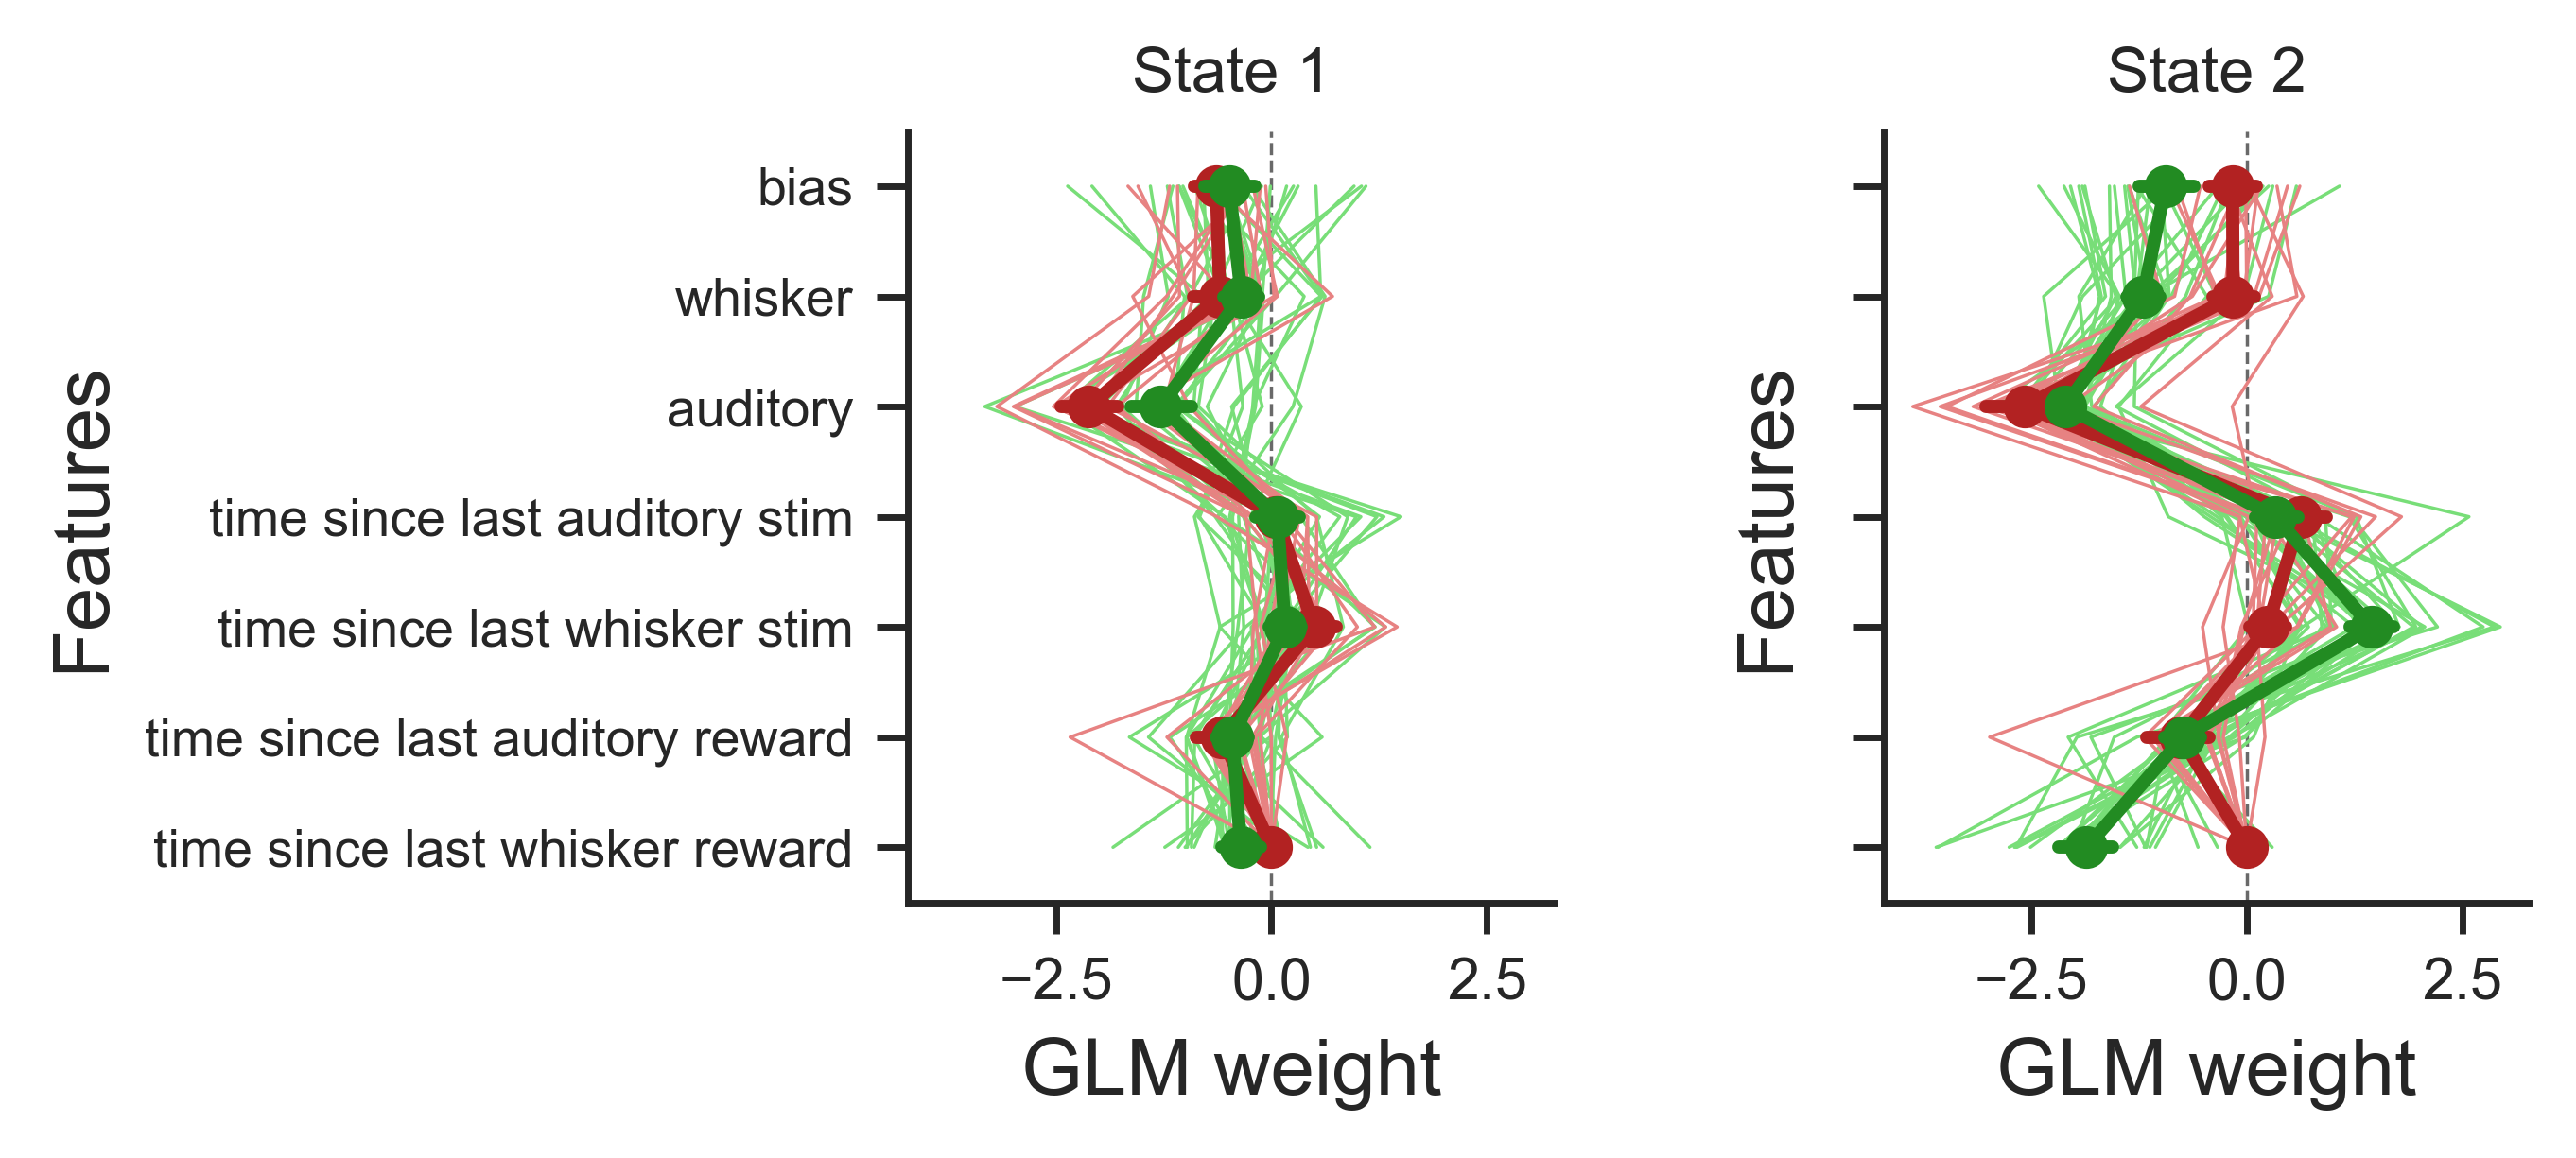

In [36]:
aligned_subjects_rewarded = np.array(aligned_subjects_rewarded)
aligned_subjects_nonrewarded = np.array(aligned_subjects_nonrewarded)
features = all_models_res_df_split['features'].unique()
fig, axs = plt.subplots(1, n_states, figsize=(3*n_states, 3), dpi=500, sharey=False, sharex=True)
all_sub_df = []
for idx, ax in enumerate(axs.flat):
    #remove_top_right_frame(ax)
    ax.axvline(0, color='dimgrey', lw=0.5, ls='--')
    # Remove underscores in feature names
    feature_labels = [f.replace('_', ' ') for f in features]
    if idx==0:
        ax.set_yticks(range(7), feature_labels, rotation=0, ha='right', fontsize=8)
    
for i in range(aligned_subjects_rewarded.shape[0]):
    for j in range(aligned_subjects_rewarded.shape[1]):
        # Make dataframe and plot vertical orientation
        df = pd.DataFrame(aligned_subjects_rewarded[i][j], columns=['weights'])    
        df['features'] = features
        df['reward_group'] = 1
        df['state_idx'] = j
        sns.lineplot(x='weights', y='features', orient='y', data=df, ax=axs[j], lw=0.5, color=lighten_color('forestgreen', 0.5))     
        
        all_sub_df.append(df)
        
        
for i in range(aligned_subjects_nonrewarded.shape[0]):
    for j in range(aligned_subjects_nonrewarded.shape[1]):
        # Make dataframe and plot vertical orientation
        df = pd.DataFrame(aligned_subjects_nonrewarded[i][j], columns=['weights'])    
        df['features'] = features
        df['reward_group'] = 0
        df['state_idx'] = j
        sns.lineplot(x='weights', y='features', orient='y', data=df, ax=axs[j], lw=0.5, color=lighten_color('firebrick', 0.5))  
        
        all_sub_df.append(df)

# Plot mean per reward group for all states
all_sub_df = pd.concat(all_sub_df)
all_sub_df['features'] = all_sub_df['features'].astype(str)
all_sub_df['reward_group'] = all_sub_df['reward_group'].astype(str)
for j in range(n_states):
    sns.pointplot(x='weights', y='features', orient='y', data=all_sub_df[all_sub_df.state_idx==j], ax=axs[j], lw=2,
                  hue='reward_group', hue_order=['0', '1'], palette=['firebrick', 'forestgreen'], legend=False)
    axs[j].set_title(f'State {j+1}')
    axs[j].set_xlabel('GLM weight', fontsize=12)
    axs[j].set_ylabel('Features', fontsize=12)
    remove_top_right_frame(axs[j])
    frame = plt.gca()
    frame.axes.yaxis.set_ticklabels([])
    
fig.tight_layout()

# Save figure
file_name = f'{n_states}_permuted_states_models_weights_all_subjects_split_{0}'
save_figure_to_files(fig=fig, save_path=result_figure_path, file_name=file_name,
                     suffix=None, file_types=['png', 'svg'], dpi=500)

In [29]:
# For each mouse, permute state_idx in trial dataframe too
for subject_id in all_subjects_trial_data_split['subject_id'].unique():
    reward_group = all_subjects_trial_data_split.loc[all_subjects_trial_data_split['subject_id']==subject_id, 'reward_group'].iloc[0]
    if reward_group in [1,2]:
        # Permute most likely state indices using rewarded group data
        all_subjects_trial_data_split.loc[all_subjects_trial_data_split['subject_id']==subject_id, 'permuted_most_likely_state'] = all_subjects_trial_data_split.loc[all_subjects_trial_data_split['subject_id']==subject_id].apply(lambda x: perm_indices_rewarded[subject_id][x['most_likely_state']], axis=1)
        
    elif reward_group==0:
        # Permute most likely state indices using non-rewarded group data
        all_subjects_trial_data_split.loc[all_subjects_trial_data_split['subject_id']==subject_id, 'permuted_most_likely_state'] = all_subjects_trial_data_split.loc[all_subjects_trial_data_split['subject_id']==subject_id].apply(lambda x: perm_indices_nonrewarded[subject_id][x['most_likely_state']], axis=1)
        
# Keep integer formatting
all_subjects_trial_data_split['permuted_most_likely_state'] = all_subjects_trial_data_split['permuted_most_likely_state'].astype(int)


#### Calculate mouse behavioural performance across states


In [30]:
# For all mice, compute trial-specific lick rates
all_rates = []
data_sub = all_subjects_trial_data_split[all_subjects_trial_data_split.whisker==1]
rates_df = data_sub.groupby(['subject_id', 'reward_group', 'session_id', 'day', 'permuted_most_likely_state']).agg({'choice': 'mean'}).reset_index()
rates_df['trial_type'] = 'whisker'
all_rates.append(rates_df)

data_sub = all_subjects_trial_data_split[all_subjects_trial_data_split.auditory==1]
rates_df = data_sub.groupby(['subject_id', 'reward_group', 'session_id', 'day','permuted_most_likely_state']).agg({'choice': 'mean'}).reset_index()
rates_df['trial_type'] = 'auditory'
all_rates.append(rates_df)

data_sub = all_subjects_trial_data_split[(all_subjects_trial_data_split.whisker!=1) 
                                   &
                                  (all_subjects_trial_data_split.auditory!=1)]       
rates_df = data_sub.groupby(['subject_id', 'reward_group', 'session_id', 'day','permuted_most_likely_state']).agg({'choice': 'mean'}).reset_index()
rates_df['trial_type'] = 'no_stim'
all_rates.append(rates_df)

all_rates = pd.concat(all_rates)
# Assign reward group 2 to 1
all_rates['reward_group'] = all_rates['reward_group'].replace(2, 1)

In [31]:
all_rates

,subject_id,reward_group,session_id,day,permuted_most_likely_state,choice,trial_type
0,AB072,1.0,AB072_20230530_093605,0,1,0.552795,whisker
1,AB072,1.0,AB072_20230601_130415,4,0,1.000000,whisker
2,AB072,1.0,AB072_20230601_130415,4,1,0.607362,whisker
3,AB073,1.0,AB073_20230531_170347,0,0,0.026549,whisker
4,AB073,1.0,AB073_20230531_170347,0,1,0.712121,whisker
...,...,...,...,...,...,...,...
194,AB129,0.0,AB129_20240828_112850,0,1,0.153061,no_stim
195,AB129,0.0,AB129_20240829_140658,1,0,0.076923,no_stim
196,AB129,0.0,AB129_20240829_140658,1,1,0.296296,no_stim
197,AB129,0.0,AB129_20240831_125121,2,0,0.062992,no_stim


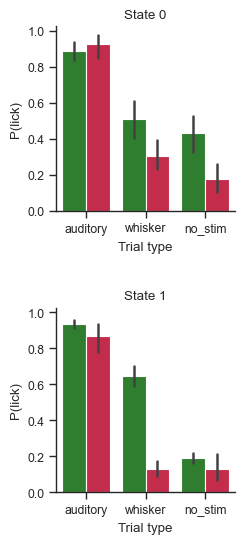

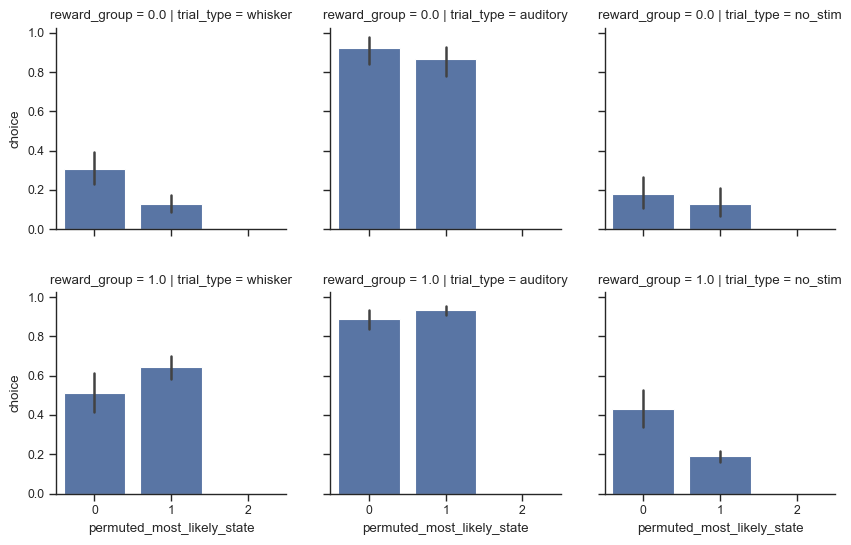

In [35]:
include_days = [0,1,2]
all_rates_days = all_rates[all_rates.day.isin(include_days)]
n_states = all_rates['permuted_most_likely_state'].nunique()
fig, axs = plt.subplots(n_states,1, figsize=(3, 3*n_states), sharey=True)

for state_idx in range(n_states):

    ax = axs[state_idx]
    sns.barplot(data=all_rates_days[all_rates_days['permuted_most_likely_state']==state_idx], x='trial_type', y='choice', 
                order=['auditory','whisker','no_stim'], hue='reward_group', hue_order=[1,0], ax=ax, legend=False, palette=['forestgreen','crimson'])
    ax.set_title(f'State {state_idx}')
    ax.set_ylabel('P(lick)')
    ax.set_xlabel('Trial type')
    remove_top_right_frame(ax)
    

# Save figure
fig.tight_layout()
file_name = f'permut_{n_states}_states_mouse_perf_all_subjects_split_{0}'
save_figure_to_files(fig=fig, save_path=result_figure_path, file_name=file_name,
                     suffix=None, file_types=['png', 'svg'], dpi=300)

# Same figure but reward group as a row instead of hue using a facet grid
g = sns.FacetGrid(all_rates_days, col='trial_type', row='reward_group', sharey=True, sharex=True, height=3, aspect=1)
g.map(sns.barplot, 'permuted_most_likely_state', 'choice', order=[0,1,2])
g.tight_layout()

# Save figure
file_name = f'permut_{n_states}_states_mouse_perf_all_subjects_split_{0}_facet'
#save_figure_to_files(fig=g, save_path=result_figure_path, file_name=file_name,
#                     suffix=None, file_types=['png', 'svg'], dpi=200)




0       1
1       0
2       0
3       0
4       0
       ..
1292    0
1293    0
1294    0
1295    0
1296    0
Name: state_bout, Length: 35258, dtype: int64

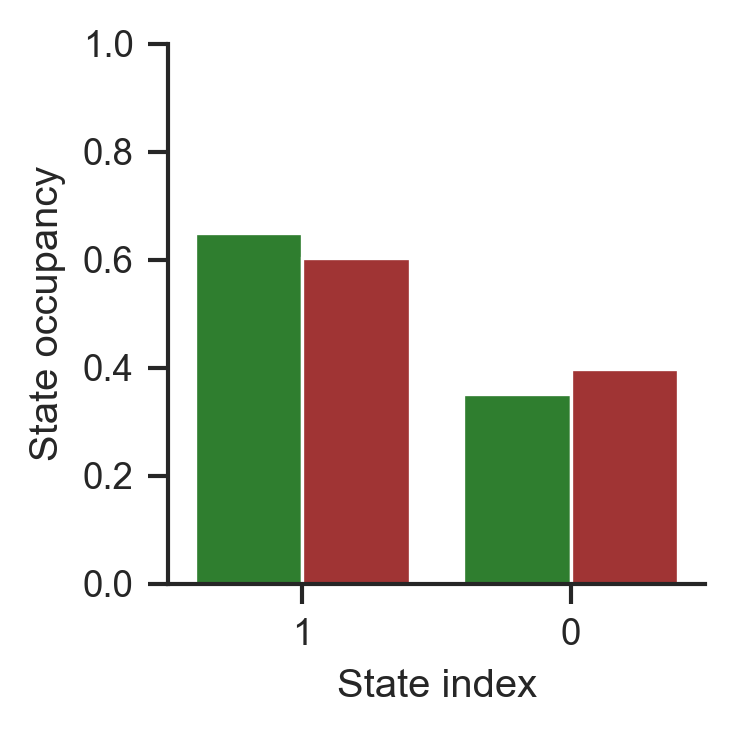

In [42]:
# Compute state occupancies
state_occupancies = all_subjects_trial_data_split.groupby(['reward_group','day'])['permuted_most_likely_state'].value_counts(normalize=True).reset_index(name='counts')
state_occupancies = state_occupancies[state_occupancies['day']==0]

# Plot state occupancy across days and reward groups
fig, ax = plt.subplots(1, 1, figsize=(3, 3), dpi=300)
remove_top_right_frame(ax)

sns.barplot(x='permuted_most_likely_state', y='counts', data=state_occupancies, ax=ax, order=[1,0],
            hue='reward_group', hue_order=[1,0], palette=['forestgreen', 'firebrick'], legend=False)
ax.set_ylabel('State occupancy')
ax.set_xlabel('State index')
ax.set_xticks(range(n_states))
ax.set_ylim(0, 1.0)

# Tight layout
fig.tight_layout()


# Save figure
file_name = f'permut_{n_states}_states_state_occupancies_all_subjects_split_{0}'
save_figure_to_files(fig=fig, save_path=result_figure_path, file_name=file_name,
                     suffix=None, file_types=['png', 'svg'], dpi=200)


# Compute dwell times in states i.e. how long the mouse stays in a state without interruptions
# Calculate bouts where mouse stays in the same state
all_subjects_trial_data_split['state_diff'] = all_subjects_trial_data_split['permuted_most_likely_state'].diff()

# If diff is not zero that means change of state, then get indices without interruptions
all_subjects_trial_data_split['state_bout'] = all_subjects_trial_data_split['state_diff'].apply(lambda x: 1 if x!=0 else 0)
all_subjects_trial_data_split['state_bout']


In [40]:
# Replace reward group 2 to 1
all_subjects_trial_data_split['reward_group'] = all_subjects_trial_data_split['reward_group'].replace(2, 1)
# Average posterior probabilities across mice
all_subjects_trial_data_split_avg = all_subjects_trial_data_split.groupby(['reward_group', 'day', 'trial_id']).agg({'posterior_0': 'mean', 'posterior_1': 'mean', 'posterior_2': 'mean'}).reset_index()


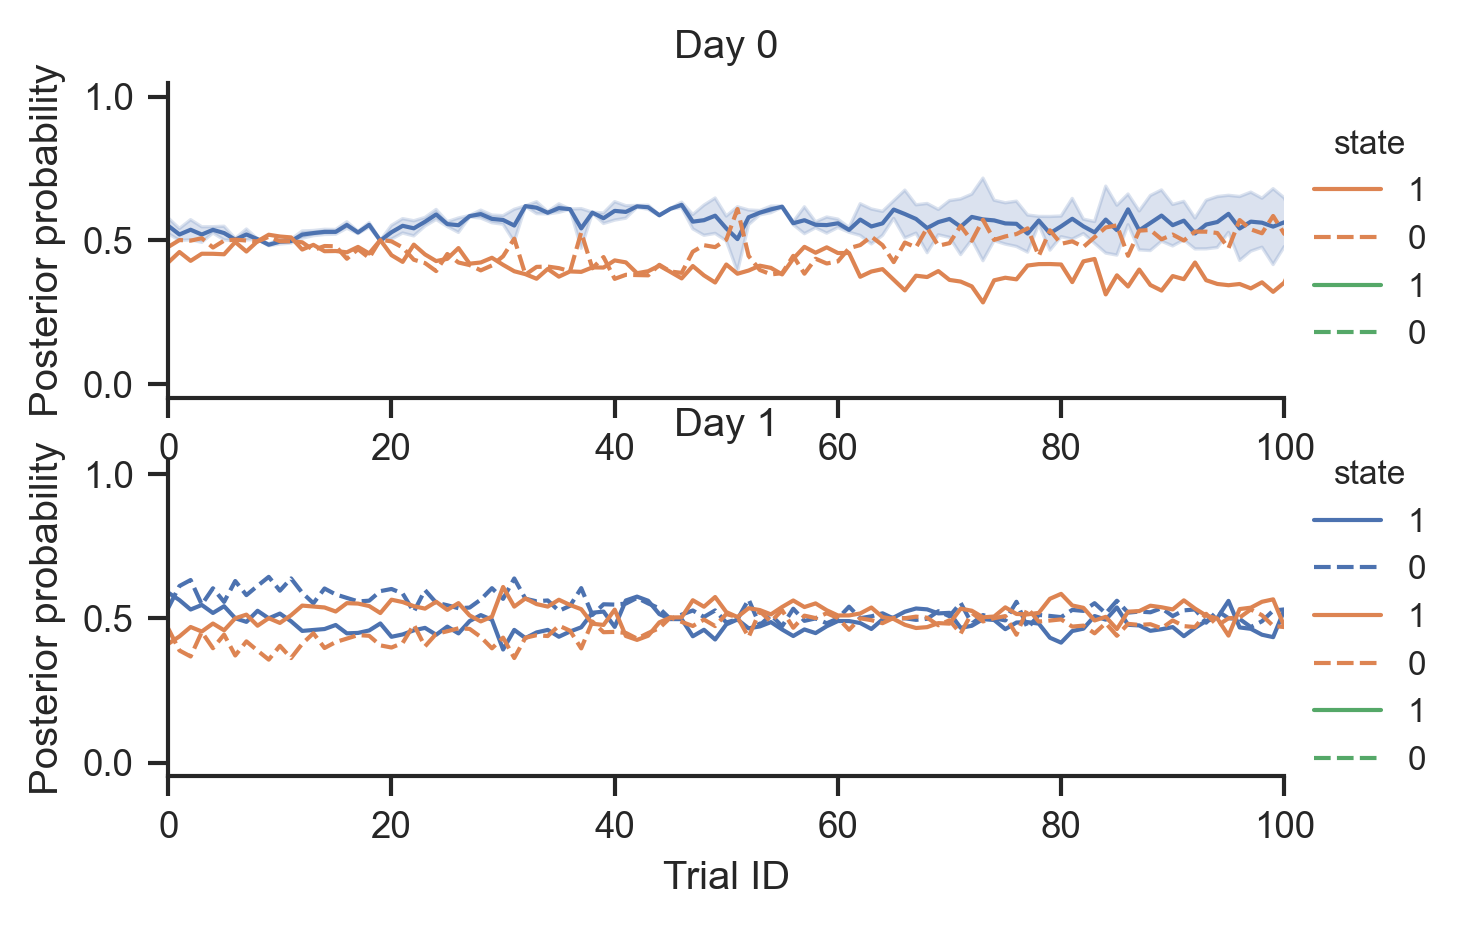

In [41]:
# Plot average posterior probabilities across mice
fig, axs = plt.subplots(2, 1, figsize=(6, 3), dpi=300)

# Day 0
axs[0].set_title('Day 0')
sns.lineplot(x='trial_id', y='posterior_0', data=all_subjects_trial_data_split_avg[all_subjects_trial_data_split_avg['day']==0], ax=axs[0], estimator=np.mean, lw=1, style=None, style_order=[1,0])
sns.lineplot(x='trial_id', y='posterior_1', data=all_subjects_trial_data_split_avg[all_subjects_trial_data_split_avg['day']==0], ax=axs[0], estimator=np.mean, lw=1, style='reward_group', style_order=[1,0])
sns.lineplot(x='trial_id', y='posterior_2', data=all_subjects_trial_data_split_avg[all_subjects_trial_data_split_avg['day']==0], ax=axs[0], estimator=np.mean, lw=1, style='reward_group', style_order=[1,0])
axs[0].set_ylabel('Posterior probability')
axs[0].set_xlabel('Trial ID')
axs[0].set_xlim(0, 100)

# Day 1
axs[1].set_title('Day 1')
sns.lineplot(x='trial_id', y='posterior_0', data=all_subjects_trial_data_split_avg[all_subjects_trial_data_split_avg['day']==1], ax=axs[1], estimator=np.mean, lw=1, style='reward_group', style_order=[1,0])
sns.lineplot(x='trial_id', y='posterior_1', data=all_subjects_trial_data_split_avg[all_subjects_trial_data_split_avg['day']==1], ax=axs[1], estimator=np.mean, lw=1, style='reward_group', style_order=[1,0])
sns.lineplot(x='trial_id', y='posterior_2', data=all_subjects_trial_data_split_avg[all_subjects_trial_data_split_avg['day']==1], ax=axs[1], estimator=np.mean, lw=1, style='reward_group', style_order=[1,0])
axs[1].set_ylabel('Posterior probability')
axs[1].set_xlabel('Trial ID')
axs[1].set_xlim(0, 100)


for ax in axs.flat:
    remove_top_right_frame(ax)
    box = ax.get_position()
    ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
    ax.legend(loc='center left', title='state', bbox_to_anchor=(1, 0.5), frameon=False, fontsize=8, title_fontsize=8)
    

In [95]:
# Find permutation

# 1. State 0 is state with largest bias, per mouse  

high_bias_state = all_models_res_df_split[all_models_res_df_split.features=='bias'].groupby('subject_id').apply(lambda x: x.loc[(x.weights).idxmin()]['state_idx']).reset_index(name='highest_bias_state') #abs or not abs
high_auditory_state = all_models_res_df_split[all_models_res_df_split.features=='auditory'].groupby('subject_id').apply(lambda x: x.loc[(x.weights).idxmin()]['state_idx']).reset_index(name='highest_aud_state') #abs or not abs
high_whisker_state = all_models_res_df_split[all_models_res_df_split.features=='whisker'].groupby('subject_id').apply(lambda x: x.loc[(x.weights.abs()).idxmax()]['state_idx']).reset_index(name='highest_wh_state') #abs or not abs

high_bias_state = pd.DataFrame(high_bias_state).reset_index()
high_auditory_state = pd.DataFrame(high_auditory_state).reset_index()
high_whisker_state = pd.DataFrame(high_whisker_state).reset_index()
high_params = pd.concat([high_bias_state, high_auditory_state, high_whisker_state], axis=1)
high_params = high_params.loc[:,~high_params.columns.duplicated()]

# Are they the same state ?
high_params['same_state'] = high_params['highest_aud_state'] == high_params['highest_wh_state']
high_params['same_state'].value_counts()
high_params

,index,subject_id,highest_bias_state,highest_aud_state,highest_wh_state,same_state
0,0,AB072,0,0,0,True
1,1,AB073,0,1,0,False
2,2,AB074,0,1,1,True
3,3,AB075,0,2,0,False
4,4,AB076,0,2,0,False
5,5,AB077,0,1,1,True
6,6,AB078,1,2,0,False
7,7,AB079,1,2,1,False
8,8,AB080,1,1,1,True
9,9,AB081,0,2,0,False


In [32]:
# Merge with all models
# If state_idx and high_aud_state_idx are different, then the state is the highest auditory state

all_models_res_df_split = all_models_res_df_split.merge(high_params, on=['subject_id']) # merge dataframes
order_by_param = 'highest_aud_state'
all_models_res_df_split['permuted_state_idx'] = all_models_res_df_split.apply(lambda x: 1 if (x['state_idx']==0)&(x[order_by_param]==1) else(1 if (x['state_idx']==1)&(x[order_by_param]==0) else 0) , axis=1)

C:\Users\bisi\AppData\Local\Temp\ipykernel_28268\2677740401.py:13: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(y='features', x='weights', data=weights_df, ax=axs[state_idx], color=color, scale=0.6)
C:\Users\bisi\AppData\Local\Temp\ipykernel_28268\2677740401.py:13: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(y='features', x='weights', data=weights_df, ax=axs[state_idx], color=color, scale=0.6)


IndexError: single positional indexer is out-of-bounds

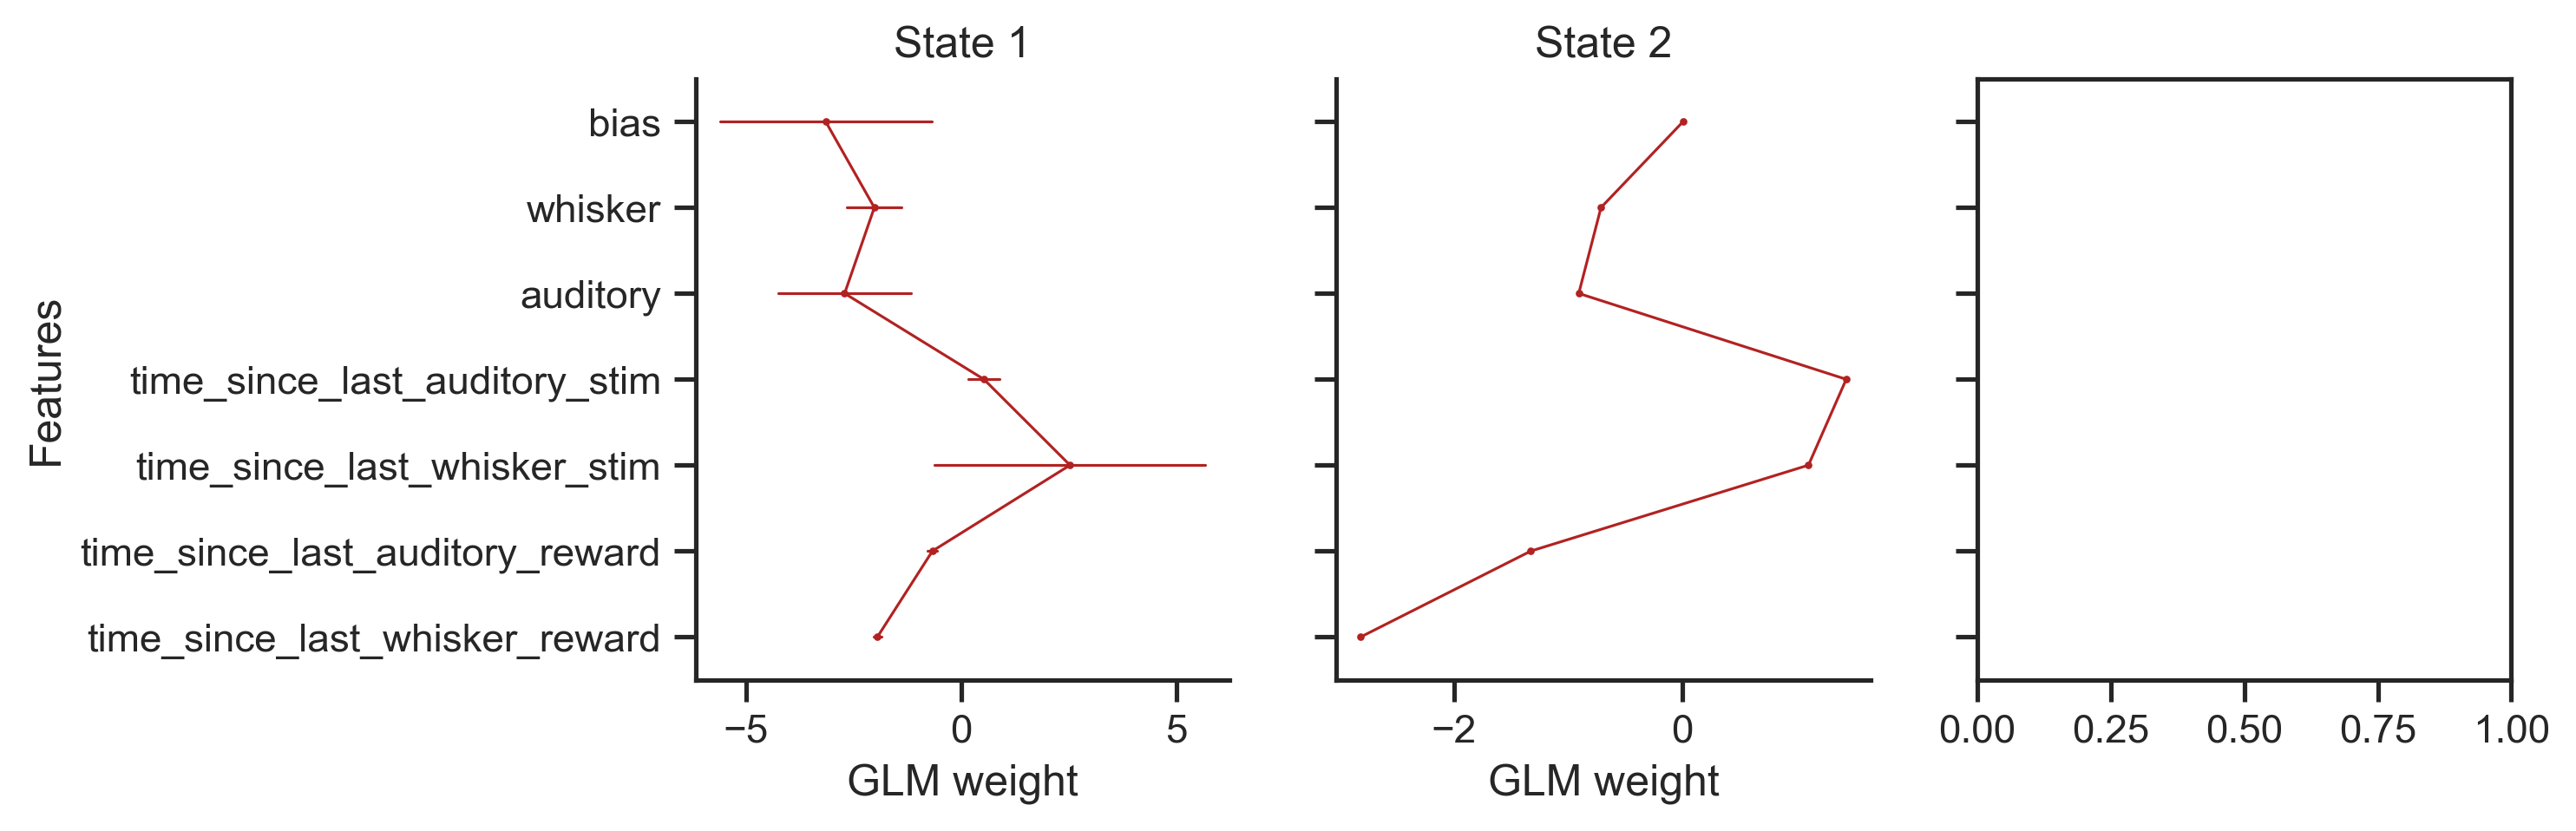

In [33]:
# Make figure including all mice
sns.set(style="ticks", rc={"lines.linewidth": 0.7})
fig, axs = plt.subplots(1, n_states, figsize=(3*n_states, 3), dpi=300, sharey=True)

for subject_id in all_models_res_df_split['subject_id'].unique():
    for state_idx in range(n_states):
        
        # Get weights and reward group
        weights_df = all_models_res_df_split[(all_models_res_df_split['subject_id']==subject_id) & (all_models_res_df_split['permuted_state_idx'] == state_idx)]
        color = 'forestgreen' if weights_df['reward_group'].iloc[0] == 1 else 'firebrick'
        
        # Plot weights and legend
        sns.pointplot(y='features', x='weights', data=weights_df, ax=axs[state_idx], color=color, scale=0.6)
        axs[state_idx].set_title(f'State {state_idx+1}')
        axs[state_idx].set_xlabel('GLM weight', fontsize=12)
        axs[state_idx].set_ylabel('Features', fontsize=12)
        remove_top_right_frame(axs[state_idx])

fig.tight_layout()

# Save figure
file_name = f'permut_{n_states}_states_models_weights_all_subjects_split_{0}_'
#save_figure_to_files(fig=fig, save_path=result_figure_path, file_name=file_name,
#                     suffix=None, file_types=['png', 'svg'], dpi=200)

In [1]:
# Make figure including all mice
sns.set(style="ticks", rc={"lines.linewidth": 0.7})
fig, axs = plt.subplots(1, n_states, figsize=(3*n_states, 3), dpi=300, sharey=True, sharex=True)

for state_idx in range(n_states):
    
    # Get weights and reward group
    weights_df = all_models_res_df_split[(all_models_res_df_split['permuted_state_idx'] == state_idx)]
    
    # Plot weights and legend
    sns.pointplot(y='features', x='weights', data=weights_df, ax=axs[state_idx], scale=1.2,
                  estimator=np.mean, ci=95, hue='reward_group',
                  hue_order=[0,1], palette=['firebrick', 'forestgreen'])
    axs[state_idx].set_title(f'State {state_idx+1}')
    axs[state_idx].set_xlabel('GLM weight', fontsize=12)
    axs[state_idx].set_ylabel('Features', fontsize=12)
    remove_top_right_frame(axs[state_idx])

fig.tight_layout()
# Remove legend
axs[0].legend().remove()
axs[1].legend().remove()


# Save figure
file_name = f'permut_{n_states}_states_models_weights_all_subjects_avg_split_{0}_'
save_figure_to_files(fig=fig, save_path=result_figure_path, file_name=file_name,
                     suffix=None, file_types=['png', 'svg'], dpi=200)

NameError: name 'sns' is not defined